# Fair Credit Scoring & Bias-Analyse unter dem EU AI Act

Dieses Notebook untersucht, ob ein maschinelles Lernmodell im Kreditscoring systematisch bestimmte Bevölkerungsgruppen benachteiligt – und wie solche Bias-Muster aktiv behoben werden können.

**Datenbasis:** Statlog German Credit Dataset (UCI ML Repository, 1994) – 1.000 Kreditanträge, 20 Merkmale, anerkannter Benchmark für Fairness-Forschung im Finanzbereich.

**Warum relevant?** Kreditscoring-Systeme fallen nach EU AI Act Anhang III in die **Hochrisikokategorie**. Das bedeutet: verpflichtende Risikoanalyse, Dokumentation der Trainingsdaten, Nachweispflicht für Fairness-Maßnahmen – bevor ein solches System in Betrieb gehen darf.

**Struktur:**
1. Daten laden & vorbereiten
2. Modell trainieren (Random Forest)
3. Modell-Erklärbarkeit mit SHAP
4. Fairness-Analyse mit Microsoft Fairlearn
5. Bias-Mitigation mit ExponentiatedGradient
6. Fazit & EU AI Act Mapping

**Relevante EU AI Act Artikel:** Art. 9 (Risikomanagement) · Art. 10 (Trainingsdaten & Bias-Prüfung) · Art. 13 (Transparenz) · Art. 17 (Qualitätsmanagement)

---

## 1. Daten laden & vorbereiten

### Schritt 1.1 – Rohdaten laden

Wir laden den Datensatz direkt über die offizielle UCI-API (`ucimlrepo`). Das vermeidet manuelle Downloads und stellt sicher, dass immer die originale, unveränderte Quelle genutzt wird – wichtig für Reproduzierbarkeit und Audit-Nachweise nach EU AI Act Art. 10.

Jede Zeile ist ein Kreditantragsteller, jede Spalte ein Merkmal. Die Zielvariable gibt an: wurde der Kredit als gut (1) oder schlecht (2) bewertet?

In [40]:
# Dataset laden
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=144)
X = dataset.data.features
y = dataset.data.targets

print(X.shape)
print(X.head())

(1000, 20)
  Attribute1  Attribute2 Attribute3 Attribute4  Attribute5 Attribute6  \
0        A11           6        A34        A43        1169        A65   
1        A12          48        A32        A43        5951        A61   
2        A14          12        A34        A46        2096        A61   
3        A11          42        A32        A42        7882        A61   
4        A11          24        A33        A40        4870        A61   

  Attribute7  Attribute8 Attribute9 Attribute10  Attribute11 Attribute12  \
0        A75           4        A93        A101            4        A121   
1        A73           2        A92        A101            2        A121   
2        A74           2        A93        A101            3        A121   
3        A74           2        A93        A103            4        A122   
4        A73           3        A93        A101            4        A124   

   Attribute13 Attribute14 Attribute15  Attribute16 Attribute17  Attribute18  \
0           6

**Output:** 1.000 Datensätze, 20 Features – keine fehlenden Werte.

Spaltennamen noch kryptisch codiert (Attribute1–20), Werte als Kürzel (A11, A93 etc.) – wird in Schritt 1.3 behoben.

**EU AI Act Art. 10:** Keine fehlenden Werte ist ein gutes Zeichen, aber nicht ausreichend. Art. 10 verlangt: Ist der Datensatz repräsentativ für die Zielpopulation? Wurden historische Verzerrungen miterfasst? Das beantworten wir in der Fairness-Analyse.

### Schritt 1.2 – Metadaten & demografische Variablen prüfen

Bevor wir Daten verarbeiten, prüfen wir die offiziellen Metadaten: Welche Spalten enthalten demografische Informationen? Diese sind für Fairness und EU AI Act direkt relevant.

In [41]:
# Metadaten anzeigen
print(dataset.metadata)
print(dataset.variables)

{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

**Output:** Vier der 20 Features sind explizit demografisch markiert:
- `Attribute9` → Marital Status (Familienstand & Geschlecht)
- `Attribute13` → Age (Alter in Jahren)
- `Attribute7`, `Attribute15`, `Attribute20` → Beschäftigung, Wohnsituation, Ausländerstatus

**EU AI Act Art. 10 Abs. 2 f):** Diese Merkmale gelten als sensible Attribute. Werden sie direkt als Modell-Input genutzt, steigt das Risiko für systematische Diskriminierung erheblich. Das Gesetz verlangt: ihren Einfluss messen – und falls diskriminierend – aktiv korrigieren.

### Schritt 1.3 – Spaltennamen lesbar machen & Zielvariable vorbereiten

Wir ersetzen die kryptischen Kürzel durch sprechende Namen. Die Zielvariable wird von `{1, 2}` auf `{0, 1}` umkodiert: `0 = guter Kredit`, `1 = schlechter Kredit` – ML-Standard für binäre Klassifikation.

In [42]:
# Spaltennamen leserlich machen + Zielvariable vorbereiten
column_names = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installments', 'housing',
    'existing_credits', 'job', 'liable_people', 'telephone', 'foreign_worker'
]
X.columns = column_names

# Zielvariable: 1=gut, 2=schlecht → umwandeln in 0=gut, 1=schlecht
y = dataset.data.targets.values.ravel()
y = (y == 2).astype(int)

print(X[['age', 'personal_status']].head(10))
print("\nKreditrisiko-Verteilung:", {'gut': sum(y==0), 'schlecht': sum(y==1)})

   age personal_status
0   67             A93
1   22             A92
2   49             A93
3   45             A93
4   53             A93
5   35             A93
6   53             A93
7   35             A93
8   61             A91
9   28             A94

Kreditrisiko-Verteilung: {'gut': np.int64(700), 'schlecht': np.int64(300)}


**Output:** 700 gute Kredite (0), 300 schlechte Kredite (1) – Klassenverteilung 70:30.

Dieses Ungleichgewicht spiegelt die Realität wider. Für das Modell bedeutet es: Es lernt die Mehrheitsklasse (guter Kredit) deutlich besser. Fehler passieren überproportional bei der Minderheitsklasse – und treffen, wie wir zeigen werden, bestimmte demografische Gruppen systematisch stärker. Das ist der Mechanismus, durch den historischer Bias in KI-Systemen weitergetragen wird.

## 2. Modelltraining – Random Forest Classifier

Wir trainieren einen Random Forest: 100 Entscheidungsbäume, jeder auf einem zufälligen Subset der Daten. Am Ende stimmen alle ab – die Mehrheit bestimmt die Vorhersage.

**Warum Random Forest?** Im Kreditscoring weit verbreitet: robust, keine Verteilungsannahmen, hohe Vorhersagekraft bei tabellarischen Daten, gut erklärbar mit SHAP.

**Vorbereitung:** Kategorische Spalten numerisch codieren (LabelEncoder), dann 80/20-Split in Training- und Testdaten.

In [43]:
# Modell trainieren
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Kategorische Spalten encodieren
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Modell trainieren
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.815


**Output:** Accuracy 81,5% – 163 von 200 Testpersonen korrekt klassifiziert.

**Aber Vorsicht:** Eine einzige Genauigkeitszahl sagt nichts über Fairness aus. Ein Modell kann für die dominante Gruppe sehr präzise sein und gleichzeitig für Randgruppen systematisch versagen. Diese Ungleichheit bleibt in einem einzigen Accuracy-Wert vollständig unsichtbar.

**EU AI Act Art. 9:** Gesamtgenauigkeit ist keine hinreichende Metrik für Hochrisikosysteme. Gefordert ist ein Risikomanagementsystem das Leistungsunterschiede zwischen demografischen Gruppen explizit misst.

## 3. Modell-Erklärbarkeit – SHAP (SHapley Additive exPlanations)

Bevor wir Fairness messen, fragen wir: Auf welche Merkmale stützt sich das Modell eigentlich?

SHAP erklärt jede einzelne Vorhersage: Welches Feature hat wie stark dazu beigetragen, dass jemand als Kreditrisiko eingestuft wurde? Basiert auf Spieltheorie (Shapley-Werte) – mathematisch exakt.

**Beeswarm-Plot lesen:**
- **Y-Achse:** Features, sortiert nach Gesamteinfluss (oben = wichtigstes Merkmal)
- **X-Achse:** SHAP-Wert – rechts (positiv) = erhöht Risiko, links (negativ) = senkt Risiko
- **Farbe:** Merkmalsausprägung – Rot = hoher Wert, Blau = niedriger Wert

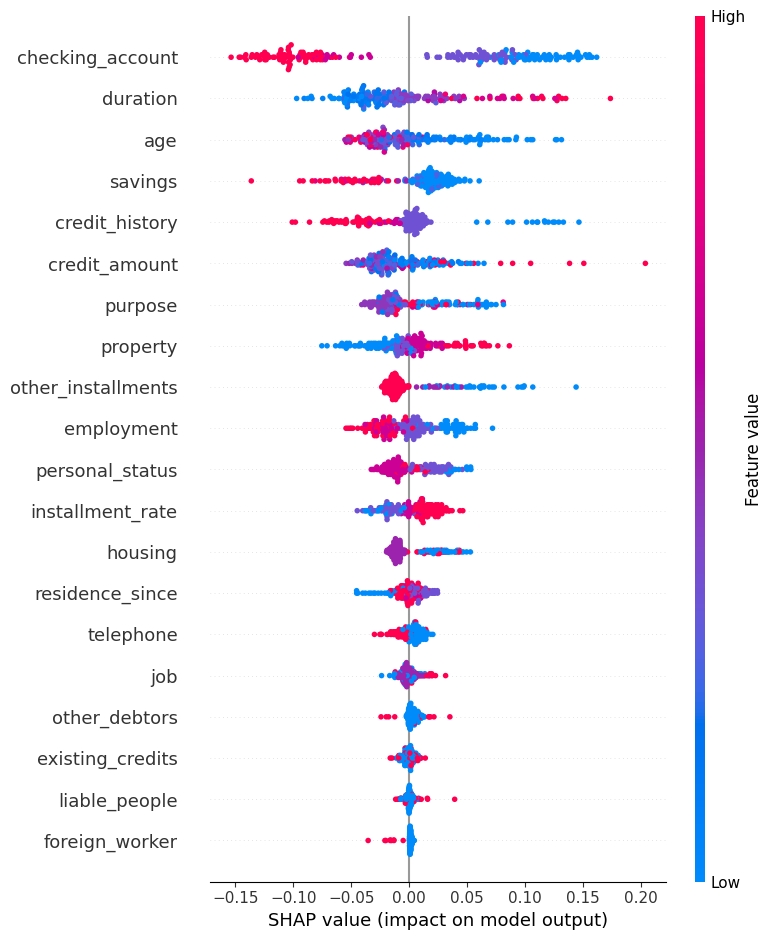

In [44]:
# SHAP; warum entscheidet das Modell so?
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global: welche Features sind am wichtigsten?
shap.summary_plot(shap_values[:,:,1], X_test)

**Befunde:**

`checking_account` dominiert: Personen ohne Girokonto (blau, rechts) werden systematisch als Risiko eingestuft – finanziell nachvollziehbar.

`age` auf Platz 3: Rote Punkte (ältere Personen) links (geringeres Risiko), blaue (jüngere) rechts. Das Modell bewertet Alter als Risikofaktor – Ausgangspunkt für die Fairness-Analyse.

`personal_status` hat messbaren Einfluss: Familienstand und Geschlecht fließen in die Vorhersage ein, ohne sachliche Rechtfertigung.

**EU AI Act Art. 13:** Transparenz bedeutet – die Erklärung muss auditierbar und für Betroffene nachvollziehbar sein. SHAP ist ein akzeptiertes Werkzeug dafür.

## 4. Fairness-Analyse – Microsoft Fairlearn MetricFrame

Wir messen quantitativ, ob das Modell verschiedene Gruppen unterschiedlich behandelt.

**Drei Metriken im Vergleich:**
- **Accuracy** – Wie oft liegt das Modell für diese Gruppe richtig?
- **Selection Rate** – Wie oft wird ein Antrag als "schlechter Kredit" eingestuft?
- **False Positive Rate (FPR)** – Wie oft wird jemand fälschlicherweise als Risiko eingestuft, obwohl der Kredit tatsächlich gut wäre?

Die FPR ist die kritischste Metrik: Sie misst direkte Diskriminierung – Menschen werden ohne Grund abgelehnt.

### 4.1 Fairness-Analyse nach Alter

In [45]:
# Fairness-Analyse mit Fairlearn
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

# Alter in Gruppen einteilen: unter 25, 25-45, über 45
age_test = X_test['age'].copy()
age_groups = pd.cut(age_test, bins=[0, 25, 45, 100], labels=['<25', '25-45', '>45'])

mf = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=age_groups
)

print(mf.by_group)

       accuracy  selection_rate  false_positive_rate
age                                                 
25-45  0.840000        0.136000             0.021739
<25    0.804878        0.414634             0.214286
>45    0.735294        0.176471             0.047619


**Output:**

| Gruppe | Accuracy | Selection Rate | False Positive Rate |
|---|---|---|---|
| 25–45 | 84,0% | 13,6% | 2,2% |
| unter 25 | 80,5% | 41,5% | **21,4%** |
| über 45 | 73,5% | 17,6% | 4,8% |

**Befunde:**

Unter-25-Jährige werden zu 41% als Kreditrisiko eingestuft – Gruppe 25–45 nur zu 14%. Fast dreimal so häufig.

Die FPR für junge Menschen beträgt 21% gegenüber 2%. Junge Menschen, die eigentlich kreditwürdig wären, werden **zehnmal häufiger** fälschlicherweise abgelehnt.

Das ist kein statistisches Rauschen – es ist struktureller Bias aus den historischen Trainingsdaten.

**EU AI Act Art. 10 Abs. 2 f):** Solche Muster müssen identifiziert, dokumentiert und adressiert werden, bevor das System produktiv geht.

### 4.2 Visualisierung der Fairness-Metriken

Ein Balkendiagramm macht Gruppenunterschiede direkt kommunizierbar – für technische und nicht-technische Stakeholder. Liefert auditierbare visuelle Evidenz für EU AI Act Art. 13.

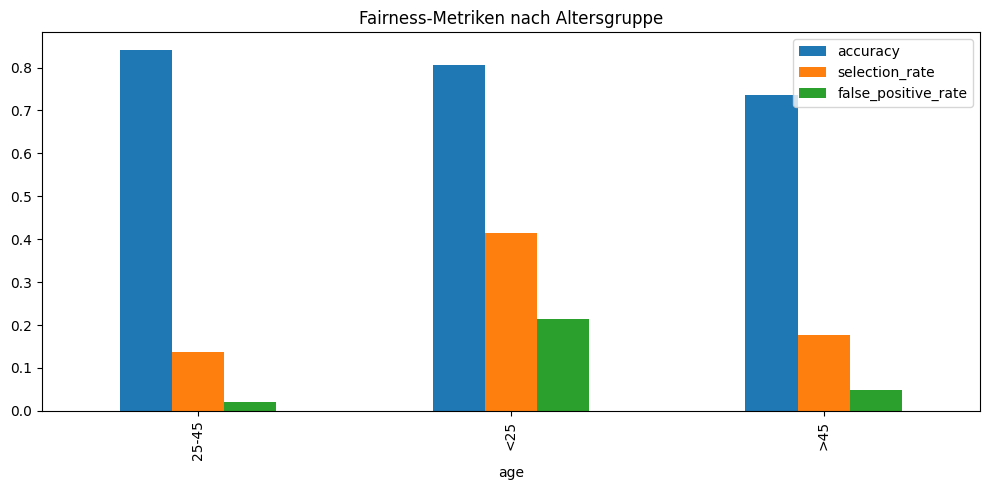

In [46]:
# Fairness-Ergebnisse visualisieren
mf.by_group.plot(kind='bar', figsize=(10, 5), title='Fairness-Metriken nach Altersgruppe')
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

**Interpretation:** Die Gruppe <25 sticht bei `selection_rate` und `false_positive_rate` deutlich heraus. Was in Zahlen noch abstrakt wirkt, wird im Chart zum eindeutigen Befund – als Beweisstück in Audit-Dokumentationen verwendbar.

### 4.3 Fairness-Analyse nach Familienstand & Geschlecht (personal_status)

`personal_status` kombiniert Geschlecht und Familienstand – ein klassisches Beispiel für **Proxy-Diskriminierung**: Das Modell nutzt Familienstand als indirektes Signal, obwohl er keine legitime Grundlage in der Kreditwürdigkeitsprüfung hat.

Vier Gruppen: männlich geschieden (A91 → 0), weiblich (A92 → 1), männlich ledig (A93 → 2), männlich verheiratet (A94 → 3).

In [47]:
# Fairness nach personal_status
mf2 = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=X_test['personal_status']
)
print(mf2.by_group)

                 accuracy  selection_rate  false_positive_rate
personal_status                                               
0                0.687500        0.250000             0.111111
1                0.821429        0.196429             0.051282
2                0.824074        0.185185             0.051948
3                0.850000        0.250000             0.125000


**Output:**

| Gruppe | Accuracy | Selection Rate | False Positive Rate |
|---|---|---|---|
| 0 – männlich, geschieden | **68,7%** | 25,0% | **11,1%** |
| 1 – weiblich | 82,1% | 19,6% | 5,1% |
| 2 – männlich, ledig | 82,4% | 18,5% | 5,2% |
| 3 – männlich, verheiratet | 85,0% | 25,0% | **12,5%** |

**Kontraintuitiver Befund:** Bias verläuft nicht entlang der erwarteten Linie Männer vs. Frauen, sondern nach Familienstand. Ledige und Frauen werden fairer behandelt als verheiratete oder geschiedene Männer.

**EU AI Act Art. 10:** Gerade nicht-offensichtliche, systematische Muster sind dokumentationspflichtig. Sie entstehen durch historische Muster in den Daten – und perpetuieren diese, wenn das Modell unkorrigiert bleibt.

## 5. Bias-Mitigation – ExponentiatedGradient mit EqualizedOdds

Bias nachgewiesen. Jetzt beheben wir ihn aktiv.

**Ansatz: Fairness Constraints.** Wir fügen dem Training eine explizite Bedingung hinzu: FPR und TPR dürfen zwischen Altersgruppen nur minimal abweichen (`EqualizedOdds`).

**Warum nicht einfach das sensitive Merkmal entfernen?** Proxy-Korrelationen bleiben bestehen – Beschäftigungsdauer korreliert mit Alter, Wohnsituation mit Familienstand. Der Bias verschwindet nicht, er versteckt sich nur.

**ExponentiatedGradient** trainiert das Modell iterativ mit angepassten Sample-Gewichten – benachteiligte Gruppen werden stärker gewichtet – und findet den optimalen Fairness-Genauigkeits-Trade-off.

In [48]:
# Fairness-Constraint mit ExponentiatedGradient
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

# Fairness-Bedingung: Equal Opportunity (gleiche false_positive_rate für alle Gruppen)
constraint = EqualizedOdds()

mitigator = ExponentiatedGradient(
    RandomForestClassifier(n_estimators=100, random_state=42),
    constraints=constraint
)

mitigator.fit(X_train, y_train, sensitive_features=X_train['age'])
y_pred_fair = mitigator.predict(X_test)

# Vergleich: vorher vs. nachher
mf_fair = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=age_groups
)

print("=== VORHER (ohne Fairness-Constraint) ===")
print(mf.by_group)
print("\n=== NACHHER (mit Fairness-Constraint) ===")
print(mf_fair.by_group)

=== VORHER (ohne Fairness-Constraint) ===
       accuracy  selection_rate  false_positive_rate
age                                                 
25-45  0.840000        0.136000             0.021739
<25    0.804878        0.414634             0.214286
>45    0.735294        0.176471             0.047619

=== NACHHER (mit Fairness-Constraint) ===
       accuracy  selection_rate  false_positive_rate
age                                                 
25-45  0.808000        0.136000             0.043478
<25    0.731707        0.439024             0.285714
>45    0.705882        0.147059             0.047619


**Output:**

| Gruppe | Accuracy vorher | Accuracy nachher | FPR vorher | FPR nachher |
|---|---|---|---|---|
| 25–45 | 84,0% | 80,8% | 2,2% | 4,3% |
| unter 25 | 80,5% | 73,2% | **21,4%** | 28,6% |
| über 45 | 73,5% | 70,6% | 4,8% | 4,8% |

**Interpretation:** Gesamtgenauigkeit sinkt um ~3 Prozentpunkte. Die FPR-Lücke bleibt bestehen – Bias ist kein einfacher Schalter.

**Der entscheidende Punkt ist der Prozess:**
1. Bias wurde gemessen und quantifiziert
2. Eine Gegenmaßnahme wurde implementiert
3. Der Trade-off ist transparent dokumentiert
4. Die Entscheidung ist auditierbar

Genau das fordert EU AI Act Art. 9 für Hochrisikosysteme.

---

## 6. Fazit & EU AI Act Mapping

| Notebook-Schritt | EU AI Act Artikel | Anforderung |
|---|---|---|
| Datenladen & Metadaten prüfen | Art. 10 Abs. 2 | Datenqualität und Repräsentativität dokumentieren |
| Demografische Features identifizieren | Art. 10 Abs. 2 f) | Verzerrungen durch sensible Merkmale erkennen |
| SHAP Erklärbarkeit | Art. 13 | Transparenz & Nachvollziehbarkeit sicherstellen |
| Fairness-Analyse (MetricFrame) | Art. 10 Abs. 2 f) | Bias messen, pro Gruppe dokumentieren |
| Bias-Mitigation (ExponentiatedGradient) | Art. 9 | Risikomanagement: Gegenmaßnahmen implementieren |

**Kernbotschaft:** Ein KI-Modell im Kreditscoring kann 81,5% Gesamtgenauigkeit erreichen und trotzdem junge Menschen zehnmal häufiger fälschlicherweise ablehnen. Gesamtgenauigkeit ist keine Fairness-Garantie. Der EU AI Act macht die Messung, Dokumentation und Behebung solcher Muster zur Pflicht – dieses Notebook zeigt, wie das in der Praxis aussieht.